In [1]:
import numpy as np
import pandas as pd
import os
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder, label_binarize
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv('E:/Works/10. Mental Health Disorder/Dataset/2_types_filtered_features_3lakh.csv')
df.head()

,text,Label,filtered_text_eng,tokenized_text,Preprocessed_Text,filtered_tokenized_words
0,"I'm done with it all. Any tips?First of all, i...",2,done with it Any of if going to comment get or...,"['done', 'go', 'comment', 'get', 'plea', 'unde...",done go comment get plea understand want hear ...,"['kill', 'pain', 'sorri', 'hate']"
1,i 20m was a problem child when grow up i frequ...,1,i was a problem child when grow up i frequent ...,"['problem', 'child', 'grow', 'frequent', 'got'...",problem child grow frequent got troubl junior ...,"['ill', 'awkward', 'steal', 'silenc', 'wrong',..."
2,I officially hate my school We have to start p...,0,I officially hate my school We have to start o...,"['offici', 'hate', 'school', 'start', 'enter',...",offici hate school start enter caus fix,"['offici', 'hate', 'school', 'start', 'enter',..."
3,but onc again depress love to take that from m...,1,but onc again depress love to take that from m...,"['onc', 'depress', 'love', 'take', 'angri', 'w...",onc depress love take angri want cri wont come...,"['cri', 'angri', 'damn', 'tire', 'depress']"
4,"Starting today, I'm going to attempt to fix my...",0,Starting going to attempt to fix my sleep sche...,"['start', 'go', 'attempt', 'fix', 'sleep', 'sc...",start go attempt fix sleep schedul school coup...,"['start', 'go', 'attempt', 'fix', 'sleep', 'sc..."


In [3]:
df1 = pd.read_csv('E:/Works/10. Mental Health Disorder/Dataset/2_types_all_features.csv')
df1.head()

,0,1,2,3,4,5,6,7,8,9,...,2781,2782,2783,2784,2785,2786,2787,2788,2789,2790
0,-0.311691,0.207526,0.294796,-0.370256,-0.463946,0.004523,0.103642,0.023245,-0.273210,-0.043930,...,1.174970,-0.131030,0.581713,1.317829,0.545300,-4.912285,2.002302,-2.429308,2.313626,0.068317
1,-0.314458,0.200302,0.248307,-0.337924,-0.354438,-0.029178,0.120759,0.028209,-0.381361,-0.010982,...,-0.170022,-1.057125,0.506787,0.481089,-0.443753,-1.015673,0.295432,-1.521313,-0.511028,-0.270724
2,-0.258834,0.199409,0.255281,-0.329083,-0.421285,-0.008494,0.122459,0.000529,-0.345936,-0.007731,...,-0.475023,-2.049421,-2.095686,-2.270150,2.747774,-4.004583,-1.818186,-3.040991,-0.021306,1.718746
3,-0.348873,0.164237,0.313819,-0.395596,-0.340182,-0.008542,0.077583,-0.002947,-0.369009,0.005620,...,1.116820,0.496508,2.048395,-0.856290,0.582634,-1.573221,0.650254,-1.483610,0.080408,-0.893238
4,-0.258569,0.201524,0.242732,-0.321395,-0.432100,-0.044947,0.111697,0.009705,-0.350573,-0.033735,...,-0.861691,-1.552952,-0.070507,-2.612564,0.754670,-5.594344,3.663493,-0.440785,1.437596,-0.616004


In [4]:
# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df1)

In [5]:
# Apply PCA
pca = PCA(n_components=100, random_state=42)
X = pca.fit_transform(X_scaled)

In [6]:
X.shape

(287398, 100)

In [7]:
y = df['Label'].values

In [8]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle = True)

# Split the training data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42, shuffle=True)

In [9]:
# Define the path to the directory where you want to save the plots
save_directory = "E:/Works/10. Mental Health Disorder/Plots/ANN"

# Ensure the directory exists
if not os.path.exists(save_directory):
    os.makedirs(save_directory)

In [10]:
import torch
print("CUDA Available:", torch.cuda.is_available())
print("GPU Count:", torch.cuda.device_count())
print("GPU Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU detected")

CUDA Available: True
GPU Count: 1
GPU Name: NVIDIA GeForce RTX 4070 Laptop GPU


In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import os
import seaborn as sns
import time

# Check if CUDA is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Define the ANN model
class ANNClassifier(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(ANNClassifier, self).__init__()
        self.fc1 = nn.Linear(input_dim, 512)
        self.bn1 = nn.BatchNorm1d(512)
        self.fc2 = nn.Linear(512, 256)
        self.bn2 = nn.BatchNorm1d(256)
        self.fc3 = nn.Linear(256, output_dim)
        self.dropout = nn.Dropout(0.5)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = self.relu(self.bn2(self.fc2(x)))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

# Convert NumPy arrays to PyTorch tensors and move to device
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.long).to(device)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val_tensor = torch.tensor(y_val, dtype=torch.long).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.long).to(device)

# Initialize datasets and loaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Model, loss function, optimizer, and scheduler
input_dim = X_train.shape[1]
output_dim = len(np.unique(y_train))
model = ANNClassifier(input_dim, output_dim).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5, verbose=True)

# Training loop with early stopping and timing
epochs = 50
patience = 10
best_val_loss = float('inf')
early_stop_counter = 0

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

start_time = time.time()

for epoch in range(epochs):
    model.train()
    epoch_train_loss = 0
    correct_train_predictions = 0
    total_train_samples = 0

    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_x)  # already on device
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        epoch_train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct_train_predictions += (predicted == batch_y).sum().item()
        total_train_samples += batch_y.size(0)

    avg_train_loss = epoch_train_loss / len(train_loader)
    avg_train_accuracy = correct_train_predictions / total_train_samples
    train_losses.append(avg_train_loss)
    train_accuracies.append(avg_train_accuracy)

    # Validation phase
    model.eval()
    epoch_val_loss = 0
    correct_val_predictions = 0
    total_val_samples = 0

    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            epoch_val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct_val_predictions += (predicted == batch_y).sum().item()
            total_val_samples += batch_y.size(0)

    avg_val_loss = epoch_val_loss / len(val_loader)
    avg_val_accuracy = correct_val_predictions / total_val_samples
    val_losses.append(avg_val_loss)
    val_accuracies.append(avg_val_accuracy)

    print(f"Epoch {epoch+1}/{epochs}, "
          f"Train Loss: {avg_train_loss:.4f}, Train Accuracy: {avg_train_accuracy:.4f}, "
          f"Val Loss: {avg_val_loss:.4f}, Val Accuracy: {avg_val_accuracy:.4f}")

    scheduler.step(avg_val_loss)

    # Early Stopping check
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        if early_stop_counter >= patience:
            print("Early stopping triggered")
            break

end_time = time.time()

Using device: cuda


E:\Works\10. Mental Health Disorder\.venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/50, Train Loss: 0.2538, Train Accuracy: 0.8935, Val Loss: 0.2045, Val Accuracy: 0.9141
Epoch 2/50, Train Loss: 0.2270, Train Accuracy: 0.9048, Val Loss: 0.1972, Val Accuracy: 0.9156
Epoch 3/50, Train Loss: 0.2205, Train Accuracy: 0.9080, Val Loss: 0.1944, Val Accuracy: 0.9176
Epoch 4/50, Train Loss: 0.2151, Train Accuracy: 0.9097, Val Loss: 0.1927, Val Accuracy: 0.9190
Epoch 5/50, Train Loss: 0.2126, Train Accuracy: 0.9107, Val Loss: 0.1923, Val Accuracy: 0.9181
Epoch 6/50, Train Loss: 0.2113, Train Accuracy: 0.9116, Val Loss: 0.1903, Val Accuracy: 0.9195
Epoch 7/50, Train Loss: 0.2090, Train Accuracy: 0.9120, Val Loss: 0.1884, Val Accuracy: 0.9203
Epoch 8/50, Train Loss: 0.2070, Train Accuracy: 0.9137, Val Loss: 0.1904, Val Accuracy: 0.9201
Epoch 9/50, Train Loss: 0.2063, Train Accuracy: 0.9138, Val Loss: 0.1889, Val Accuracy: 0.9198
Epoch 10/50, Train Loss: 0.2061, Train Accuracy: 0.9139, Val Loss: 0.1871, Val Accuracy: 0.9214
Epoch 11/50, Train Loss: 0.2043, Train Accuracy: 

In [12]:
training_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {training_time_minutes:.2f} minutes.")

Training completed in 21.13 minutes.


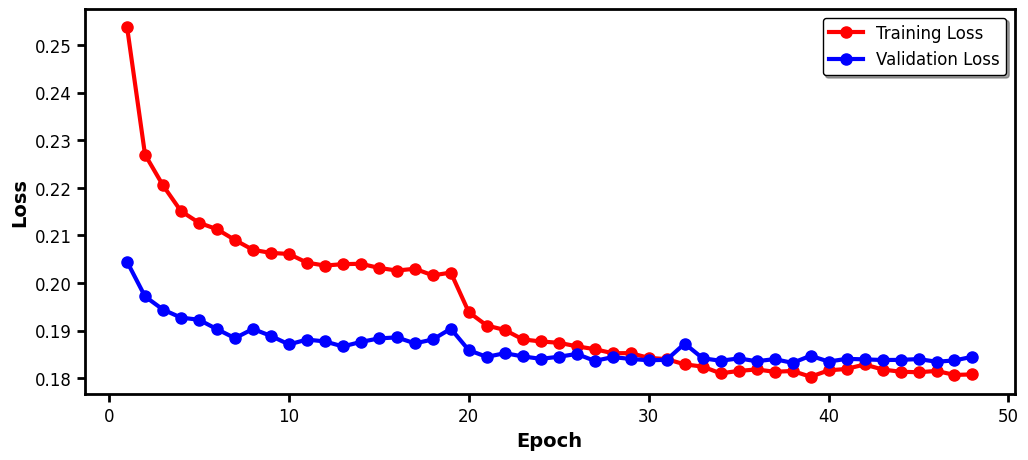

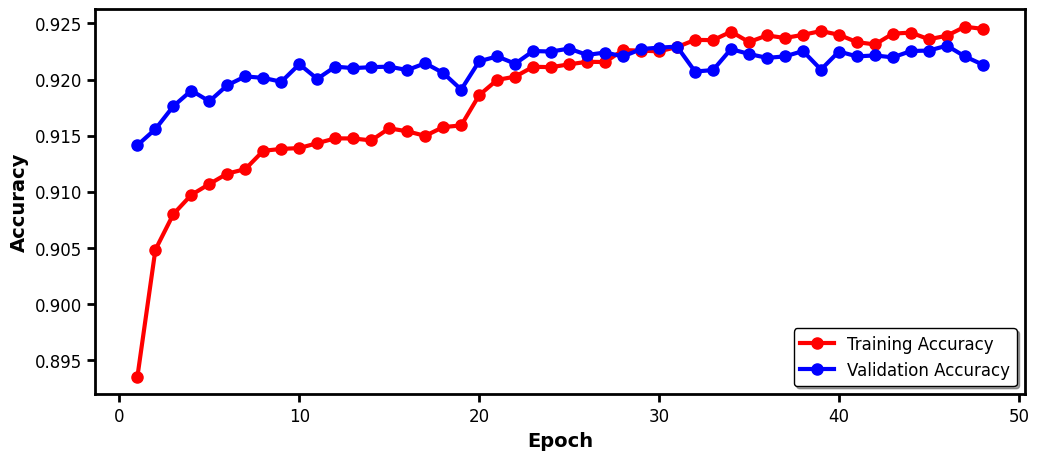

In [13]:
# Enhanced Plot for Training and Validation Loss with Brighter Colors
plt.figure(figsize=(12, 5))

# Use bright colors for the lines
plt.plot(range(1, len(train_losses) + 1), train_losses, marker='o', label='Training Loss', color='red', lw=3, markersize=8) 
plt.plot(range(1, len(val_losses) + 1), val_losses, marker='o', label='Validation Loss', color='blue', lw=3, markersize=8) 

# Increase font size and make labels bold for clarity
plt.xlabel('Epoch', fontsize=14, weight='bold', color='black')
plt.ylabel('Loss', fontsize=14, weight='bold', color='black')
#plt.title('Training and Validation Loss (ANN)', fontsize=16, weight='bold', color='black')

# Customize legend for better readability
plt.legend(fontsize=12, loc='best', frameon=True, fancybox=True, edgecolor='black', shadow=True)

# Add gridlines for better readability
plt.grid(True, linestyle='--', alpha=0.7)

# Make the axes thicker for better visibility
plt.gca().spines['top'].set_linewidth(2)
plt.gca().spines['right'].set_linewidth(2)
plt.gca().spines['bottom'].set_linewidth(2)
plt.gca().spines['left'].set_linewidth(2)

# Customize tick parameters for larger ticks
plt.tick_params(axis='both', which='major', labelsize=12, length=6, width=2)

# Disable the grid
plt.grid(False)

# Save the plot with high DPI for better resolution
plt.savefig(os.path.join(save_directory, "loss_curve_ann_enhanced_colors.png"), dpi=300, bbox_inches='tight')
plt.show()



# Enhanced Plot for Training and Validation Accuracy with Brighter Colors
plt.figure(figsize=(12, 5))

# Use bright colors for the lines
plt.plot(range(1, len(train_accuracies) + 1), train_accuracies, marker='o', label='Training Accuracy', color='red', lw=3, markersize=8)  # Bright green
plt.plot(range(1, len(val_accuracies) + 1), val_accuracies, marker='o', label='Validation Accuracy', color='blue', lw=3, markersize=8)  # Bright orange

# Increase font size and make labels bold for clarity
plt.xlabel('Epoch', fontsize=14, weight='bold', color='black')
plt.ylabel('Accuracy', fontsize=14, weight='bold', color='black')
#plt.title('Training and Validation Accuracy (ANN)', fontsize=16, weight='bold', color='black')

# Customize legend for better readability
plt.legend(fontsize=12, loc='best', frameon=True, fancybox=True, edgecolor='black', shadow=True)

# Add gridlines for better readability
plt.grid(True, linestyle='--', alpha=0.7)

# Make the axes thicker for better visibility
plt.gca().spines['top'].set_linewidth(2)
plt.gca().spines['right'].set_linewidth(2)
plt.gca().spines['bottom'].set_linewidth(2)
plt.gca().spines['left'].set_linewidth(2)

# Customize tick parameters for larger ticks
plt.tick_params(axis='both', which='major', labelsize=12, length=6, width=2)

# Disable the grid
plt.grid(False)

# Save the plot with high DPI for better resolution
plt.savefig(os.path.join(save_directory, "accuracy_curve_ann_enhanced_colors.png"), dpi=300, bbox_inches='tight')
plt.show()

In [14]:
# Evaluation for ANN
model.eval()
all_preds_ann = []
all_labels_ann = []
all_probs_ann = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        outputs = model(batch_x)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        all_preds_ann.extend(preds.cpu().tolist())
        all_labels_ann.extend(batch_y.cpu().tolist())
        all_probs_ann.extend(probs.cpu().tolist())

# Convert lists to PyTorch tensors
all_preds_ann = torch.tensor(all_preds_ann)
all_labels_ann = torch.tensor(all_labels_ann)
all_probs_ann = torch.tensor(all_probs_ann)

# Calculate metrics
accuracy_ann = (all_preds_ann == all_labels_ann).float().mean().item()

# Convert tensors to lists
y_true = all_labels_ann.tolist()
y_pred = all_preds_ann.tolist()

# Classification Report with 8 decimal places
print("Classification Report (ANN):\n", classification_report(y_true, y_pred, digits=8))

# Calculate Accuracy
accuracy = accuracy_score(y_true, y_pred)
print(f"Accuracy (ANN): {accuracy * 100:.6f}%")

# Calculate Precision (for multi-class, average='weighted')
precision = precision_score(y_true, y_pred, average='weighted')
print(f"Precision (ANN): {precision * 100:.6f}%")

# Calculate Recall (for multi-class, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
print(f"Recall (ANN): {recall * 100:.6f}%")

# Calculate F1 Score (for multi-class, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')
print(f"F1 Score (ANN): {f1 * 100:.6f}%")

Classification Report (ANN):
               precision    recall  f1-score   support

           0  0.99792741 0.99959492 0.99876047     19749
           1  0.88138882 0.89103391 0.88618512     19373
           2  0.88372992 0.87193594 0.87779332     18358

    accuracy                      0.92223382     57480
   macro avg  0.92101538 0.92085492 0.92091297     57480
weighted avg  0.92217689 0.92223382 0.92218362     57480

Accuracy (ANN): 92.223382%
Precision (ANN): 92.217689%
Recall (ANN): 92.223382%
F1 Score (ANN): 92.218362%


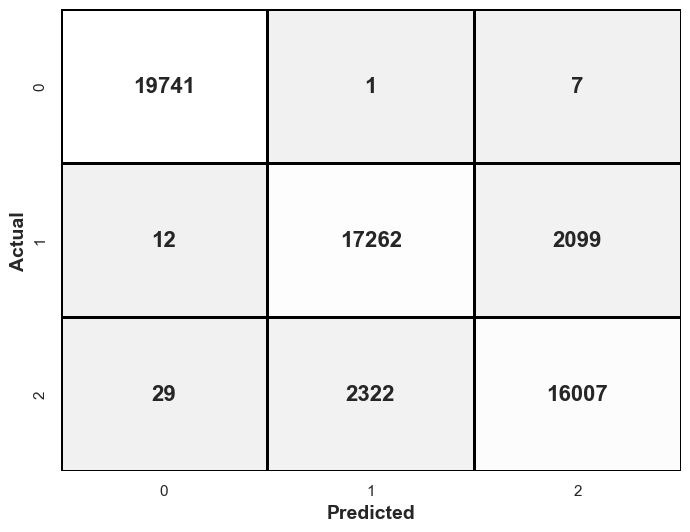

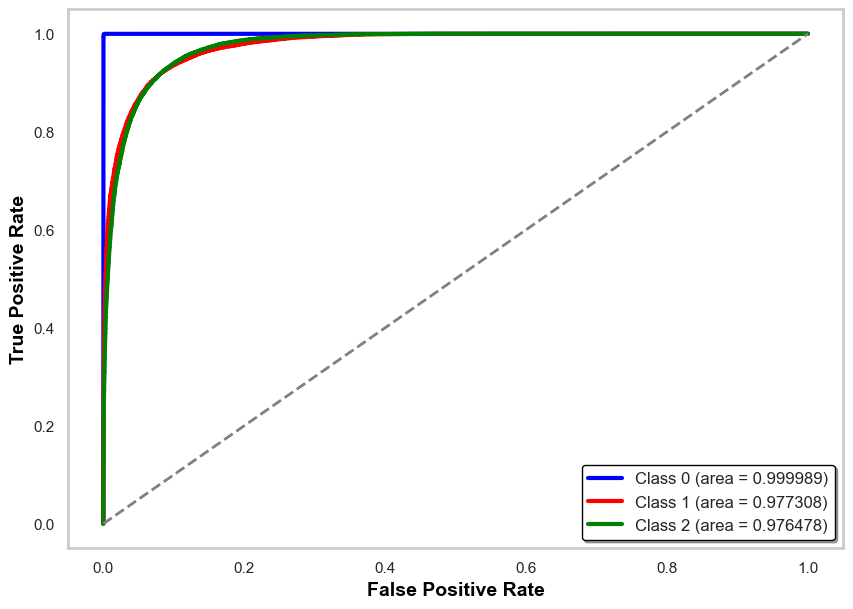

AUC for Class 0: 0.999989
AUC for Class 1: 0.977308
AUC for Class 2: 0.976478
Overall AUC Score (Weighted Average): 0.984592


In [15]:
def plot_confusion_matrix(model_name, conf_matrix, save_path):
    # Ensure the save_path directory exists
    if not os.path.exists(save_path):
        os.makedirs(save_path)

    sns.set(style="whitegrid")  # Seaborn style for cleaner plots

    conf_matrix = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))

    # Custom colormap for white background
    cmap = sns.light_palette("white", as_cmap=True)

    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap=cmap, 
                annot_kws={"size": 16, "weight": "bold"}, linewidths=2, linecolor='black', cbar=False)

    plt.xlabel('Predicted', fontsize=14, weight='bold')
    plt.ylabel('Actual', fontsize=14, weight='bold')
    #plt.title(f'Confusion Matrix ({model_name})', fontsize=18, weight='bold')

    # Thicker axis borders for sharpness
    plt.gca().spines['top'].set_linewidth(2)
    plt.gca().spines['right'].set_linewidth(2)
    plt.gca().spines['bottom'].set_linewidth(2)
    plt.gca().spines['left'].set_linewidth(2)

    # Save plot with high DPI
    plt.savefig(os.path.join(save_path, f"{model_name}_confusion_matrix_enhanced.png"), bbox_inches='tight', dpi=300)
    plt.show()
    plt.close()



def plot_roc_curve(model_name, y_test, y_prob, save_path):
    # Ensure the save_path directory exists
    if not os.path.exists(save_path):
        os.makedirs(save_path)

    # Binarize the labels for multi-class ROC AUC
    y_test_binarized = label_binarize(y_test, classes=[0, 1, 2])  # Assuming 3 classes
    n_classes = y_test_binarized.shape[1]
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    colors = ['blue', 'red', 'green']
    total_auc = 0

    # Convert y_prob from list of lists to a 2D list (list of lists)
    y_prob = [[float(prob) for prob in probs] for probs in y_prob]

    # Calculate ROC metrics and plot
    plt.figure(figsize=(10, 7))
    for i in range(n_classes):
        # Convert lists to tensors and then to numpy arrays for roc_curve
        y_test_bin = [row[i] for row in y_test_binarized]
        y_prob_class = [row[i] for row in y_prob]
        fpr[i], tpr[i], _ = roc_curve(y_test_bin, y_prob_class)
        roc_auc[i] = auc(fpr[i], tpr[i])
        total_auc += roc_auc[i]
        
        # Plot ROC curve for each class
        plt.plot(fpr[i], tpr[i], color=colors[i], lw=3,  # Increased line width for clarity
                 label='Class {0} (area = {1:0.6f})'.format(i, roc_auc[i]))

    avg_auc = total_auc / n_classes
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')

    plt.xlabel('False Positive Rate', fontsize=14, weight='bold', color='black')
    plt.ylabel('True Positive Rate', fontsize=14, weight='bold', color='black')
    #plt.title(f'ROC Curve ({model_name})', fontsize=18, weight='bold', color='black')

    # Enhance the legend with larger text, shadow, and bold font
    plt.legend(loc='lower right', fontsize=12, frameon=True, fancybox=True, edgecolor='black', shadow=True)

    # Thicker borders for a sharper look
    plt.gca().spines['top'].set_linewidth(2)
    plt.gca().spines['right'].set_linewidth(2)
    plt.gca().spines['bottom'].set_linewidth(2)
    plt.gca().spines['left'].set_linewidth(2)

    # Disable the grid
    plt.grid(False)

    # Save plot with higher DPI
    plt.savefig(os.path.join(save_path, f"{model_name}_roc_curve_enhanced.png"), bbox_inches='tight', dpi=300)
    plt.show()
    plt.close()

    # Print AUC for each class and the overall AUC score
    for i in range(n_classes):
        print(f"AUC for Class {i}: {roc_auc[i]:.6f}")
    
    print(f"Overall AUC Score (Weighted Average): {avg_auc:.6f}")

    return avg_auc


# Compute confusion matrix
conf_matrix_ann = confusion_matrix(y_test, y_pred)

# Plot and save the results
plot_confusion_matrix("ANN", conf_matrix_ann, save_directory)


y_prob = [prob for prob in all_probs_ann] 
# Compute ROC AUC manually
roc_auc_ann = plot_roc_curve("ANN", y_test, y_prob, save_directory)